# Analyze a chronological three-stage split

- Training occurs before holdout within every stage
- Holdout comes from the end of the stage
- Approximately 15% holdout where possible
- At least 200 FL and 200 NF samples in each holdout
- A 24-hour NF-only gap between training and holdout
- A 24-hour NF-only gap between major datasets


In [1]:
# Imports and file locations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the repository root.
ROOT = Path.cwd()

while not (ROOT / "data_labeling").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("Repository root could not be found.")
    ROOT = ROOT.parent

LABEL_DIR = (
    ROOT
    / "data_labeling"
    / "data_labels"
    / "simplified_data_labels"
)

OLD_LABELS = LABEL_DIR / "labels_2010_2018_binary.csv"
NEW_LABELS = LABEL_DIR / "labels_2019_2026_july_binary.csv"

print("Repository:", ROOT)
print("2010–2018 labels:", OLD_LABELS)
print("2019–2026 labels:", NEW_LABELS)

Repository: /Users/piyushluitel/Desktop/PhD/Research/Full-Disk-Attention---Continual-Learning-
2010–2018 labels: /Users/piyushluitel/Desktop/PhD/Research/Full-Disk-Attention---Continual-Learning-/data_labeling/data_labels/simplified_data_labels/labels_2010_2018_binary.csv
2019–2026 labels: /Users/piyushluitel/Desktop/PhD/Research/Full-Disk-Attention---Continual-Learning-/data_labeling/data_labels/simplified_data_labels/labels_2019_2026_july_binary.csv


In [2]:
# Load and combine the labels
old_data = pd.read_csv(OLD_LABELS)
new_data = pd.read_csv(NEW_LABELS)

data = pd.concat(
    [old_data, new_data],
    ignore_index=True,
)


In [3]:
data


,label,goes_class
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,0
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,0
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,0
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,0
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,0
...,...,...
128088,2026/07/31/HMI.m2026.07.31_19.00.00.jpg,0
128089,2026/07/31/HMI.m2026.07.31_20.00.00.jpg,0
128090,2026/07/31/HMI.m2026.07.31_21.00.00.jpg,0
128091,2026/07/31/HMI.m2026.07.31_22.00.00.jpg,0


In [4]:
timestamp_text = data["label"].str.extract(
    r"HMI\.m(\d{4}\.\d{2}\.\d{2}_\d{2}\.\d{2}\.\d{2})"
)[0]

data["timestamp"] = pd.to_datetime(
    timestamp_text,
    format="%Y.%m.%d_%H.%M.%S",
)

data

,label,goes_class,timestamp
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,0,2010-12-06 07:00:00
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,0,2010-12-06 08:00:00
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,0,2010-12-06 09:00:00
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,0,2010-12-06 10:00:00
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,0,2010-12-06 11:00:00
...,...,...,...
128088,2026/07/31/HMI.m2026.07.31_19.00.00.jpg,0,2026-07-31 19:00:00
128089,2026/07/31/HMI.m2026.07.31_20.00.00.jpg,0,2026-07-31 20:00:00
128090,2026/07/31/HMI.m2026.07.31_21.00.00.jpg,0,2026-07-31 21:00:00
128091,2026/07/31/HMI.m2026.07.31_22.00.00.jpg,0,2026-07-31 22:00:00


In [5]:
data = (
    data
    .sort_values("timestamp")
    .drop_duplicates("label")
    .reset_index(drop=True)
)

data

,label,goes_class,timestamp
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,0,2010-12-06 07:00:00
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,0,2010-12-06 08:00:00
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,0,2010-12-06 09:00:00
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,0,2010-12-06 10:00:00
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,0,2010-12-06 11:00:00
...,...,...,...
128088,2026/07/31/HMI.m2026.07.31_19.00.00.jpg,0,2026-07-31 19:00:00
128089,2026/07/31/HMI.m2026.07.31_20.00.00.jpg,0,2026-07-31 20:00:00
128090,2026/07/31/HMI.m2026.07.31_21.00.00.jpg,0,2026-07-31 21:00:00
128091,2026/07/31/HMI.m2026.07.31_22.00.00.jpg,0,2026-07-31 22:00:00


In [6]:
assert data["timestamp"].notna().all()
assert data["goes_class"].isin([0, 1]).all()
assert data["label"].is_unique

In [7]:
print("Total samples:", f"{len(data):,}")
print("First timestamp:", data["timestamp"].min())
print("Last timestamp:", data["timestamp"].max())

Total samples: 128,093
First timestamp: 2010-12-06 07:00:00
Last timestamp: 2026-07-31 23:00:00


In [10]:
# Function for displaying a distribution
def distribution(name, frame):
    total = len(frame)
    fl = int(frame["goes_class"].sum())
    nf = total - fl

    return {
        "dataset": name,
        "start": frame["timestamp"].min(),
        "end": frame["timestamp"].max(),
        "samples": total,
        "FL": fl,
        "NF": nf,
        "FL_percent": 100 * fl / total,
    }

In [11]:
# Inspect the yearly distribution
data["year"] = data["timestamp"].dt.year

data

,label,goes_class,timestamp,year
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,0,2010-12-06 07:00:00,2010
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,0,2010-12-06 08:00:00,2010
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,0,2010-12-06 09:00:00,2010
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,0,2010-12-06 10:00:00,2010
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,0,2010-12-06 11:00:00,2010
...,...,...,...,...
128088,2026/07/31/HMI.m2026.07.31_19.00.00.jpg,0,2026-07-31 19:00:00,2026
128089,2026/07/31/HMI.m2026.07.31_20.00.00.jpg,0,2026-07-31 20:00:00,2026
128090,2026/07/31/HMI.m2026.07.31_21.00.00.jpg,0,2026-07-31 21:00:00,2026
128091,2026/07/31/HMI.m2026.07.31_22.00.00.jpg,0,2026-07-31 22:00:00,2026


In [12]:
yearly_distribution = (
    data.groupby("year")["goes_class"]
    .agg(samples="size", FL="sum")
)

yearly_distribution["NF"] = (
    yearly_distribution["samples"]
    - yearly_distribution["FL"]
)

yearly_distribution["FL_percent"] = (
    100
    * yearly_distribution["FL"]
    / yearly_distribution["samples"]
)

display(yearly_distribution)

,samples,FL,NF,FL_percent
year,,,,
2010,562,0,562,0.000000
2011,6528,1235,5293,18.918505
2012,6516,1358,5158,20.841007
2013,7656,1436,6220,18.756531
2014,8405,2702,5703,32.147531
2015,8511,1664,6847,19.551169
2016,8337,250,8087,2.998681
2017,8377,330,8047,3.939358
2018,8393,0,8393,0.000000


In [ ]:
# Find complete 24-hour NF-only gaps
# searches through a time-series pandas DataFrame to identify every window of 24 consecutive hourly 
# observations where no solar flares occurred (represented as "NF" or "No Flare").
def find_nf_gaps(frame):
    """
    Return the starting times of every complete 24-hour NF-only gap.
    """
    frame = frame.sort_values("timestamp").reset_index(drop=True)

    times = frame["timestamp"].to_numpy()
    targets = frame["goes_class"].to_numpy()

    # gap_starts to record match timestamps.
    gap_starts = []

    for index in range(len(frame) - 23):
        complete_24_hours = (
            times[index + 23] - times[index]
            == np.timedelta64(23, "h")
        )

        all_no_flare = targets[index:index + 24].sum() == 0

        if complete_24_hours and all_no_flare:
            gap_starts.append(pd.Timestamp(times[index]))
# returns the starting timestamp for every 24-hour period that passes both checks.
    return gap_starts

In [15]:
ALL_NF_GAPS = find_nf_gaps(data)
ALL_NF_GAPS

[Timestamp('2010-12-06 07:00:00'),
 Timestamp('2010-12-06 08:00:00'),
 Timestamp('2010-12-06 09:00:00'),
 Timestamp('2010-12-06 10:00:00'),
 Timestamp('2010-12-06 11:00:00'),
 Timestamp('2010-12-06 12:00:00'),
 Timestamp('2010-12-06 13:00:00'),
 Timestamp('2010-12-06 14:00:00'),
 Timestamp('2010-12-06 15:00:00'),
 Timestamp('2010-12-06 16:00:00'),
 Timestamp('2010-12-06 17:00:00'),
 Timestamp('2010-12-06 18:00:00'),
 Timestamp('2010-12-06 19:00:00'),
 Timestamp('2010-12-10 00:00:00'),
 Timestamp('2010-12-10 01:00:00'),
 Timestamp('2010-12-11 07:00:00'),
 Timestamp('2010-12-11 08:00:00'),
 Timestamp('2010-12-11 09:00:00'),
 Timestamp('2010-12-11 10:00:00'),
 Timestamp('2010-12-11 11:00:00'),
 Timestamp('2010-12-11 12:00:00'),
 Timestamp('2010-12-11 13:00:00'),
 Timestamp('2010-12-11 14:00:00'),
 Timestamp('2010-12-11 15:00:00'),
 Timestamp('2010-12-11 16:00:00'),
 Timestamp('2010-12-11 17:00:00'),
 Timestamp('2010-12-11 18:00:00'),
 Timestamp('2010-12-11 19:00:00'),
 Timestamp('2010-12-

In [18]:
# finds the single closest 24-hour flare-free period to a specific target date.
ALL_NF_GAPS = find_nf_gaps(data)

def nearest_nf_gap(target_time, search_days=30):
    """
    Find the closest NF-only 24-hour gap to a desired boundary.
    """
    target_time = pd.Timestamp(target_time)

    nearby_gaps = [
        gap
        for gap in ALL_NF_GAPS
        if abs(gap - target_time) <= pd.Timedelta(days=search_days)
    ]

    if not nearby_gaps:
        raise ValueError(
            f"No NF-only 24-hour gap found near {target_time}."
        )

    return min(
        nearby_gaps,
        key=lambda gap: abs(gap - target_time),
    )

In [22]:
# Select the major boundaries
# Stage 1 and Stage 2 already have a natural 25-hour separation
STAGE2_STAGE3_GAP = nearest_nf_gap("2023-07-01")
STAGE3_VALIDATION_GAP = nearest_nf_gap("2024-07-01")
VALIDATION_TEST_GAP = nearest_nf_gap("2025-07-01")




In [23]:
STAGE2_STAGE3_GAP, STAGE3_VALIDATION_GAP, VALIDATION_TEST_GAP

(Timestamp('2023-06-29 23:00:00'),
 Timestamp('2024-06-29 11:00:00'),
 Timestamp('2025-07-01 00:00:00'))

In [24]:
boundary_gaps = pd.DataFrame(
    [
        {
            "boundary": "Stage 2 → Stage 3",
            "gap_start": STAGE2_STAGE3_GAP,
            "gap_end": STAGE2_STAGE3_GAP + pd.Timedelta(hours=23),
        },
        {
            "boundary": "Stage 3 → Validation",
            "gap_start": STAGE3_VALIDATION_GAP,
            "gap_end": STAGE3_VALIDATION_GAP + pd.Timedelta(hours=23),
        },
        {
            "boundary": "Validation → Test",
            "gap_start": VALIDATION_TEST_GAP,
            "gap_end": VALIDATION_TEST_GAP + pd.Timedelta(hours=23),
        },
    ]
)

display(boundary_gaps)

,boundary,gap_start,gap_end
0,Stage 2 → Stage 3,2023-06-29 23:00:00,2023-06-30 22:00:00
1,Stage 3 → Validation,2024-06-29 11:00:00,2024-06-30 10:00:00
2,Validation → Test,2025-07-01 00:00:00,2025-07-01 23:00:00


In [28]:
# Construct the five chronological blocks
stage1_complete = data[
    data["timestamp"] < pd.Timestamp("2019-01-01")
].copy()

In [26]:
stage2_complete = data[
    (data["timestamp"] >= pd.Timestamp("2019-01-01"))
    & (data["timestamp"] < STAGE2_STAGE3_GAP)
].copy()

stage3_complete = data[
    (
        data["timestamp"]
        >= STAGE2_STAGE3_GAP + pd.Timedelta(hours=24)
    )
    & (
        data["timestamp"]
        < STAGE3_VALIDATION_GAP
    )
].copy()

validation_data = data[
    (
        data["timestamp"]
        >= STAGE3_VALIDATION_GAP + pd.Timedelta(hours=24)
    )
    & (
        data["timestamp"]
        < VALIDATION_TEST_GAP
    )
].copy()

test_data = data[
    data["timestamp"]
    >= VALIDATION_TEST_GAP + pd.Timedelta(hours=24)
].copy()

In [29]:
# Display the main dataset distributions
main_summary = pd.DataFrame(
    [
        distribution("Stage 1 complete", stage1_complete),
        distribution("Stage 2 complete", stage2_complete),
        distribution("Stage 3 complete", stage3_complete),
        distribution("Validation", validation_data),
        distribution("Test", test_data),
    ]
)

display(main_summary)

,dataset,start,end,samples,FL,NF,FL_percent
0,Stage 1 complete,2010-12-06 07:00:00,2018-12-30 23:00:00,63285,8975,54310,14.181876
1,Stage 2 complete,2019-01-01 00:00:00,2023-06-29 22:00:00,38407,4865,33542,12.666962
2,Stage 3 complete,2023-06-30 23:00:00,2024-06-29 10:00:00,8649,3929,4720,45.427217
3,Validation,2024-06-30 11:00:00,2025-06-30 23:00:00,8493,4142,4351,48.769575
4,Test,2025-07-02 00:00:00,2026-07-31 23:00:00,9187,3018,6169,32.850767


In [30]:
def create_end_holdout(
    stage_data,
    target_fraction=0.15,
    minimum_fl=200,
    minimum_nf=200,
    maximum_shift_days=200,
):
    """
    Split one stage into:

        earlier training data
        24-hour NF-only gap
        later holdout data

    The selected split is as close as possible to the requested
    holdout percentage while satisfying the FL and NF requirements.
    """
    stage_data = (
        stage_data
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    target_index = int(len(stage_data) * (1 - target_fraction))
    target_time = stage_data.iloc[target_index]["timestamp"]

    times = stage_data["timestamp"].to_numpy()
    targets = stage_data["goes_class"].to_numpy()

    candidates = []

    for index in range(len(stage_data) - 23):
        gap_start = pd.Timestamp(times[index])

        if (
            abs(gap_start - target_time)
            > pd.Timedelta(days=maximum_shift_days)
        ):
            continue

        complete_gap = (
            times[index + 23] - times[index]
            == np.timedelta64(23, "h")
        )

        nf_only_gap = targets[index:index + 24].sum() == 0

        if not (complete_gap and nf_only_gap):
            continue

        training = stage_data.iloc[:index].copy()
        holdout = stage_data.iloc[index + 24:].copy()

        holdout_fl = int(holdout["goes_class"].sum())
        holdout_nf = len(holdout) - holdout_fl

        if holdout_fl < minimum_fl or holdout_nf < minimum_nf:
            continue

        retained_samples = len(training) + len(holdout)
        holdout_fraction = len(holdout) / retained_samples

        candidates.append(
            {
                "difference_from_target": abs(
                    holdout_fraction - target_fraction
                ),
                "distance_from_target": abs(
                    gap_start - target_time
                ),
                "gap_start": gap_start,
                "gap_end": gap_start + pd.Timedelta(hours=23),
                "training": training,
                "holdout": holdout,
                "holdout_fraction": holdout_fraction,
            }
        )

    if not candidates:
        raise ValueError(
            "No valid chronological holdout was found."
        )

    best = min(
        candidates,
        key=lambda item: (
            item["difference_from_target"],
            item["distance_from_target"],
        ),
    )

    return best

In [31]:
stage1_split = create_end_holdout(stage1_complete)
stage2_split = create_end_holdout(stage2_complete)
stage3_split = create_end_holdout(stage3_complete)

splits = {
    1: stage1_split,
    2: stage2_split,
    3: stage3_split,
}

In [32]:
split_rows = []

for stage_number, split in splits.items():
    train_row = distribution(
        f"Stage {stage_number} train",
        split["training"],
    )

    holdout_row = distribution(
        f"Stage {stage_number} holdout",
        split["holdout"],
    )

    train_row["holdout_percent"] = np.nan
    holdout_row["holdout_percent"] = (
        100 * split["holdout_fraction"]
    )

    split_rows.extend([train_row, holdout_row])

split_summary = pd.DataFrame(split_rows)

display(split_summary)

,dataset,start,end,samples,FL,NF,FL_percent,holdout_percent
0,Stage 1 train,2010-12-06 07:00:00,2017-07-12 01:00:00,50998,8755,42243,17.167340,NaN
1,Stage 1 holdout,2017-07-13 02:00:00,2018-12-30 23:00:00,12263,220,12043,1.794015,19.384771
2,Stage 2 train,2019-01-01 00:00:00,2022-10-28 18:00:00,32626,2411,30215,7.389812,NaN
3,Stage 2 holdout,2022-10-29 19:00:00,2023-06-29 22:00:00,5757,2454,3303,42.626368,14.998828
4,Stage 3 train,2023-06-30 23:00:00,2024-05-06 05:00:00,7352,3115,4237,42.369423,NaN
5,Stage 3 holdout,2024-05-07 06:00:00,2024-06-29 10:00:00,1273,814,459,63.943441,14.759420


In [33]:
# Display all removed internal gaps
internal_gaps = pd.DataFrame(
    [
        {
            "stage": stage_number,
            "gap_start": split["gap_start"],
            "gap_end": split["gap_end"],
            "removed_samples": 24,
        }
        for stage_number, split in splits.items()
    ]
)

display(internal_gaps)

,stage,gap_start,gap_end,removed_samples
0,1,2017-07-12 02:00:00,2017-07-13 01:00:00,24
1,2,2022-10-28 19:00:00,2022-10-29 18:00:00,24
2,3,2024-05-06 06:00:00,2024-05-07 05:00:00,24


In [34]:
# Verify chronology and class requirements
for stage_number, split in splits.items():
    training = split["training"]
    holdout = split["holdout"]

    training_fl = int(training["goes_class"].sum())
    holdout_fl = int(holdout["goes_class"].sum())
    holdout_nf = len(holdout) - holdout_fl

    assert training["timestamp"].max() < split["gap_start"]
    assert split["gap_end"] < holdout["timestamp"].min()

    assert holdout_fl >= 200
    assert holdout_nf >= 200

    assert set(training["label"]).isdisjoint(
        set(holdout["label"])
    )

assert stage1_complete["timestamp"].max() < stage2_complete["timestamp"].min()
assert stage2_complete["timestamp"].max() < stage3_complete["timestamp"].min()
assert stage3_complete["timestamp"].max() < validation_data["timestamp"].min()
assert validation_data["timestamp"].max() < test_data["timestamp"].min()

all_output_frames = [
    splits[1]["training"],
    splits[1]["holdout"],
    splits[2]["training"],
    splits[2]["holdout"],
    splits[3]["training"],
    splits[3]["holdout"],
    validation_data,
    test_data,
]

all_output_labels = pd.concat(
    [frame["label"] for frame in all_output_frames],
    ignore_index=True,
)

assert all_output_labels.is_unique

print("All chronological and overlap checks passed.")

All chronological and overlap checks passed.


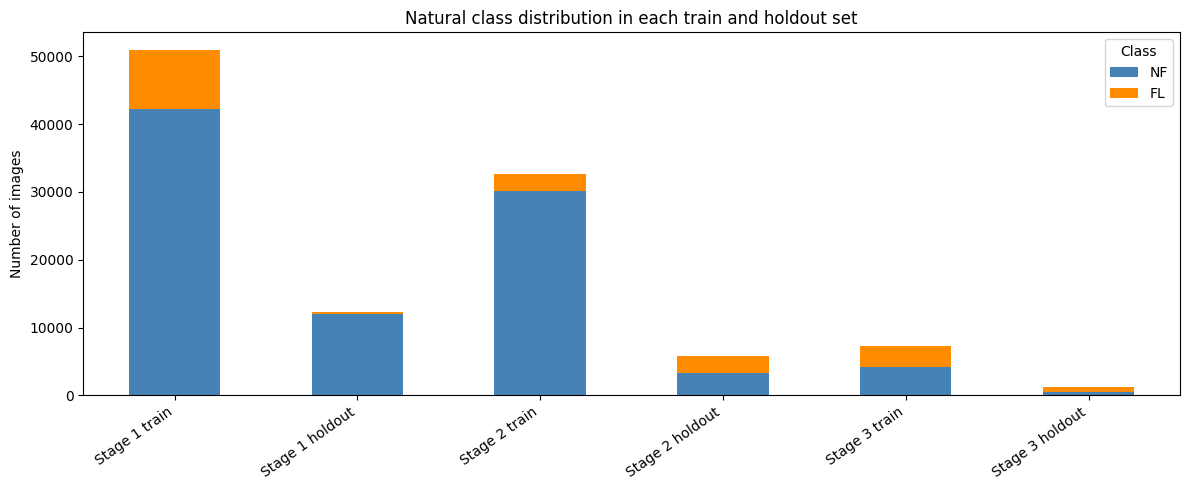

In [35]:
plot_data = split_summary.set_index("dataset")[["NF", "FL"]]

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    color=["steelblue", "darkorange"],
)

ax.set_title("Natural class distribution in each train and holdout set")
ax.set_xlabel("")
ax.set_ylabel("Number of images")
ax.legend(title="Class")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [36]:
future_summary = pd.DataFrame(
    [
        distribution("Validation", validation_data),
        distribution("Test", test_data),
    ]
)

display(future_summary)

,dataset,start,end,samples,FL,NF,FL_percent
0,Validation,2024-06-30 11:00:00,2025-06-30 23:00:00,8493,4142,4351,48.769575
1,Test,2025-07-02 00:00:00,2026-07-31 23:00:00,9187,3018,6169,32.850767
